# Efficiency frontier results

Flickr30k Karpathy test is the primary, uncontaminated evaluation. COCO validation is supplementary and was used for selection in earlier phases.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, display

ROOT = Path('..') if Path('../results').exists() else Path('.')
OUT = ROOT / 'results/efficiency_frontier'
frontier = pd.read_csv(OUT / 'frontier.csv')
frontier

,entry_id,label,role,row_type,seed,flickr_i2t_R1,flickr_t2i_R1,flickr_mean_R1,coco_validation_i2t_R1,coco_validation_t2i_R1,...,cpu_tokenization_median_ms,latency_node,latency_gpu,seed43_latency_median_ms,seed43_minus_seed42_latency_ms,flickr_parameter_pareto,flickr_latency_iqr_pareto,flickr_latency_raw_median_pareto,flickr_R1_per_million_parameters,flickr_R1_per_ms
0,locked_minilm,DINOv3 ViT-S/16 + MiniLM (locked recipe),main_student,seed,42.0,0.485000,0.368600,0.426800,0.436200,0.308867,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,locked_minilm,DINOv3 ViT-S/16 + MiniLM (locked recipe),main_student,seed,43.0,0.477000,0.369600,0.423300,0.427400,0.307668,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,locked_minilm,DINOv3 ViT-S/16 + MiniLM (locked recipe),main_student,seed,44.0,0.465000,0.379000,0.422000,0.428400,0.304110,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,locked_minilm,DINOv3 ViT-S/16 + MiniLM (locked recipe),main_student,aggregate,NaN,0.475667,0.372400,0.424033,0.430667,0.306881,...,14.042513,aisurrey38.surrey.ac.uk,NVIDIA RTX PRO 6000 Blackwell Server Edition,17.047653,-0.303072,True,False,False,0.009263,0.024439
4,locked_e5,DINOv3 ViT-S/16 + E5-Small-v2 (best available ...,best_available_configuration,seed,42.0,0.510000,0.384800,0.447400,0.449200,0.312305,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,locked_e5,DINOv3 ViT-S/16 + E5-Small-v2 (best available ...,best_available_configuration,seed,43.0,0.529000,0.385000,0.457000,0.448200,0.314064,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,locked_e5,DINOv3 ViT-S/16 + E5-Small-v2 (best available ...,best_available_configuration,seed,44.0,0.494000,0.385000,0.439500,0.450800,0.315263,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,locked_e5,DINOv3 ViT-S/16 + E5-Small-v2 (best available ...,best_available_configuration,aggregate,NaN,0.511000,0.384933,0.447967,0.449400,0.313878,...,14.058887,aisurrey38.surrey.ac.uk,NVIDIA RTX PRO 6000 Blackwell Server Edition,24.820646,-0.078543,True,False,False,0.007939,0.017991
8,historical_v4,"DINOv3 ViT-S/16 + MiniLM (v4 recipe, before co...",before_correction,seed,42.0,0.205000,0.150800,0.177900,0.146400,0.105701,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,historical_v4,"DINOv3 ViT-S/16 + MiniLM (v4 recipe, before co...",before_correction,seed,43.0,0.207000,0.149600,0.178300,0.150400,0.107500,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [2]:
aggregate = frontier[frontier.row_type == 'aggregate']
aggregate[['label', 'flickr_i2t_R1', 'flickr_t2i_R1', 'flickr_mean_R1',
           'full_stack_inference_parameters', 'query_side_inference_parameters',
           'latency_median_ms', 'native_text_context_length']]

,label,flickr_i2t_R1,flickr_t2i_R1,flickr_mean_R1,full_stack_inference_parameters,query_side_inference_parameters,latency_median_ms,native_text_context_length
3,DINOv3 ViT-S/16 + MiniLM (locked recipe),0.475667,0.372400,0.424033,45778563.0,23452417.0,17.350725,512.0
7,DINOv3 ViT-S/16 + E5-Small-v2 (best available ...,0.511000,0.384933,0.447967,56425347.0,34099201.0,24.899189,512.0
11,"DINOv3 ViT-S/16 + MiniLM (v4 recipe, before co...",0.207667,0.152200,0.179933,45778563.0,23452417.0,17.052074,512.0
12,MobileCLIP2-S0:dfndr2b,0.875000,0.689800,0.782400,74835073.0,63428096.0,21.334739,77.0
13,ViT-B-32-SigLIP2-256:webli,0.882000,0.729600,0.805800,376856066.0,282303744.0,11.733865,64.0
14,ViT-B-32-quickgelu:openai,0.787000,0.577400,0.682200,151277313.0,63428096.0,9.411086,77.0


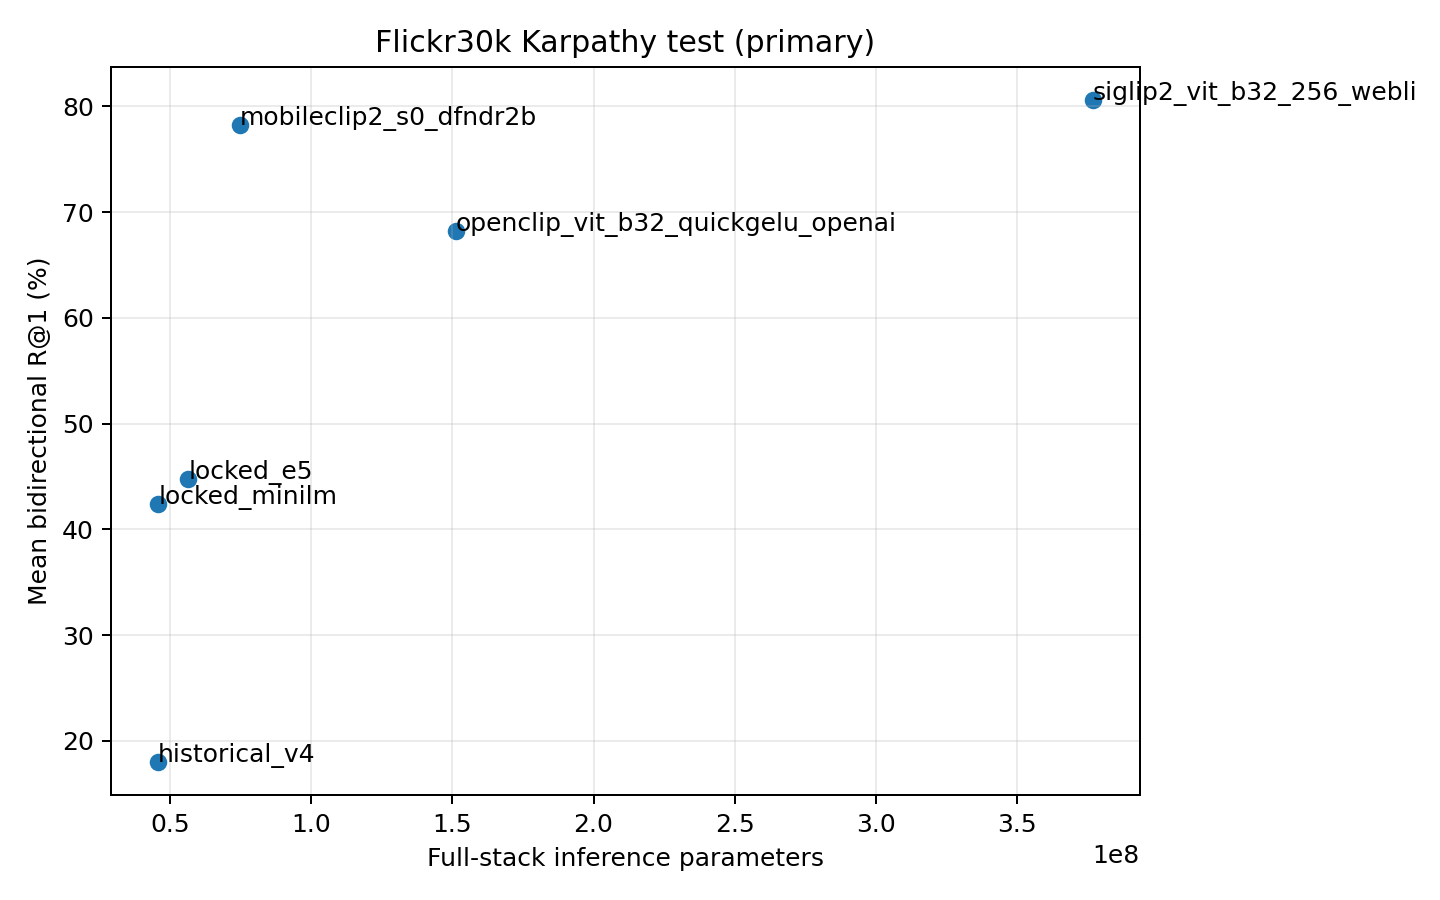

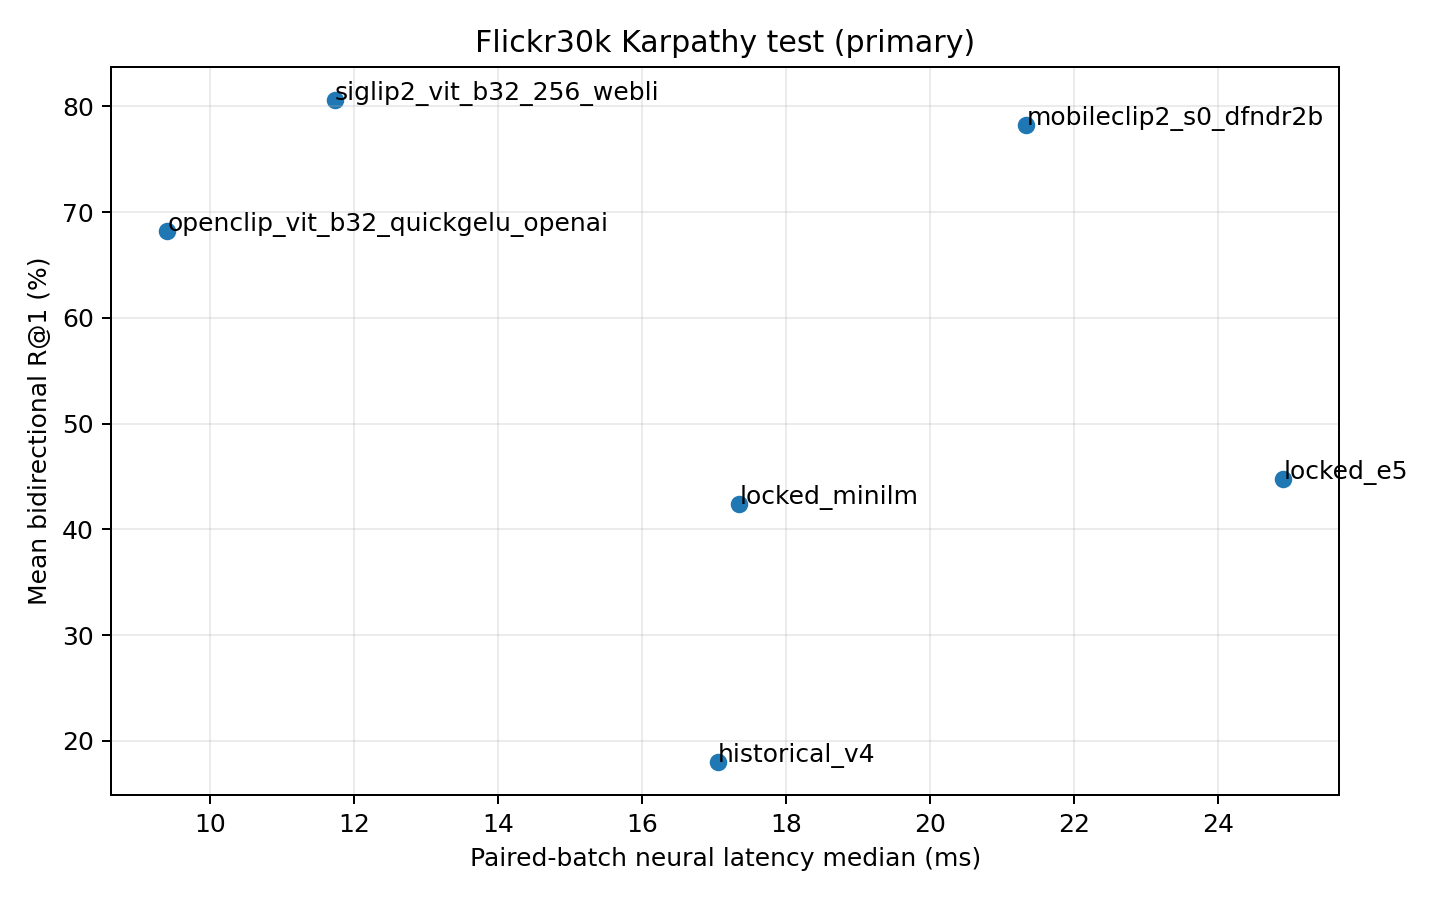

In [3]:
display(Image(filename=OUT / 'plots/flickr_r1_vs_parameters.png'))
display(Image(filename=OUT / 'plots/flickr_r1_vs_latency.png'))

In [4]:
pd.read_csv(OUT / 'tables/recipe_correction.csv')

,entry_id,label,role,row_type,seed,flickr_i2t_R1,flickr_t2i_R1,flickr_mean_R1,coco_validation_i2t_R1,coco_validation_t2i_R1,...,cpu_tokenization_median_ms,latency_node,latency_gpu,seed43_latency_median_ms,seed43_minus_seed42_latency_ms,flickr_parameter_pareto,flickr_latency_iqr_pareto,flickr_latency_raw_median_pareto,flickr_R1_per_million_parameters,flickr_R1_per_ms
0,locked_minilm,DINOv3 ViT-S/16 + MiniLM (locked recipe),main_student,aggregate,NaN,0.475667,0.3724,0.424033,0.430667,0.306881,...,14.042513,aisurrey38.surrey.ac.uk,NVIDIA RTX PRO 6000 Blackwell Server Edition,17.047653,-0.303072,True,False,False,0.009263,0.024439
1,historical_v4,"DINOv3 ViT-S/16 + MiniLM (v4 recipe, before co...",before_correction,aggregate,NaN,0.207667,0.1522,0.179933,0.148200,0.106207,...,14.027028,aisurrey38.surrey.ac.uk,NVIDIA RTX PRO 6000 Blackwell Server Edition,17.112793,0.060719,False,False,False,0.003931,0.010552


In [5]:
json.loads((OUT / 'report.json').read_text())

{'status': 'COMPLETE',
 'primary_dataset': 'Flickr30k Karpathy test',
 'supplementary_dataset': 'COCO validation (used for model selection in earlier project phases; not an independent test set)',
 'untouched_coco_test_available': False,
 'parameter_frontier': ['locked_e5',
  'locked_minilm',
  'mobileclip2_s0_dfndr2b',
  'siglip2_vit_b32_256_webli'],
 'latency_iqr_frontier': ['openclip_vit_b32_quickgelu_openai',
  'siglip2_vit_b32_256_webli'],
 'latency_raw_median_frontier': ['openclip_vit_b32_quickgelu_openai',
  'siglip2_vit_b32_256_webli'],
 'latency_frontier_difference': [],
 'flop_convention': "One multiply-add is two FLOPs. Projection and normalization are included. Caption FLOPs use each model's native context and are not directly comparable across differing context lengths.",
 'limitations': ['The project has no COCO test split that was never used by an earlier selection procedure.',
  'Flickr30k is the only uncontaminated evaluation available for the frontier.',
  'The Flickr